In [1]:
"""
# Recreate the architecture in Streamlit
model = Build_HyperCNNmodel(num_classes=num_classes, model_save_path=...).build(best_hps)

# Load the weights
model.load_weights(r"D:\D\adsw\DSA\hvc\capstone\models\final_plant_disease_model.weights.h5")
"""

<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
C:\Users\suman\AppData\Local\Temp\ipykernel_4244\711086709.py:6: SyntaxWarning: invalid escape sequence '\D'
  model.load_weights(r"D:\D\adsw\DSA\hvc\capstone\models\final_plant_disease_model.weights.h5")


'\n# Recreate the architecture in Streamlit\nmodel = Build_HyperCNNmodel(num_classes=num_classes, model_save_path=...).build(best_hps)\n\n# Load the weights\nmodel.load_weights(r"D:\\D\x07dsw\\DSA\\hvc\\capstone\\models\x0cinal_plant_disease_model.weights.h5")\n'

In [2]:
# 1. Install gdown cleanly
!pip install --quiet gdown

# 2. Download directly using the ID parameter to avoid string merging bugs
import gdown
file_id = '1C60AFlEb9FPFfp9WkXbNcINwrv6e-sIU'
output = 'dataset.zip'

gdown.download(id=file_id, output=output, quiet=False)

# 3. Extract your dataset into the working directory
import zipfile
with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("/kaggle/working/dataset")

print("Extraction complete! Your files are ready.")

Downloading...
From (original): https://drive.google.com/uc?id=1C60AFlEb9FPFfp9WkXbNcINwrv6e-sIU
From (redirected): https://drive.google.com/uc?id=1C60AFlEb9FPFfp9WkXbNcINwrv6e-sIU&confirm=t&uuid=16e54ee2-2468-4fdf-a652-b2e442ae18fc
To: /kaggle/working/dataset.zip
100%|██████████| 950M/950M [00:09<00:00, 104MB/s]  


Extraction complete! Your files are ready.


================================================== Dataset Folder Validation ==================================================
path exists! Found 39 class subfolders
Sample folder names:
  - Tomato___Tomato_mosaic_virus
  - Tomato___Target_Spot
  - Pepper,_bell___healthy
  - Soybean___healthy
  - Corn___Common_rust
  - Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  - Cherry___Powdery_mildew
  - Apple___Black_rot
  - Strawberry___Leaf_scorch
  - Peach___healthy
  - Corn___Cercospora_leaf_spot Gray_leaf_spot
  - Pepper,_bell___Bacterial_spot
  - Background_without_leaves
  - Tomato___Late_blight
  - Corn___Northern_Leaf_Blight
  - Grape___Black_rot
  - Apple___Apple_scab
  - Apple___healthy
  - Tomato___Spider_mites Two-spotted_spider_mite
  - Tomato___Bacterial_spot
  - Tomato___Tomato_Yellow_Leaf_Curl_Virus
  - Potato___Early_blight
  - Blueberry___healthy
  - Tomato___Leaf_Mold
  - Raspberry___healthy
  - Grape___Esca_(Black_Measles)
  - Potato___Late_blight
  - Tomato___Septoria_leaf_

I0000 00:00:1781868999.976379      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



--- Dataset Info ---
Total Images: 61486
Total Classes: 39
================================================== random dataset  validation ==================================================


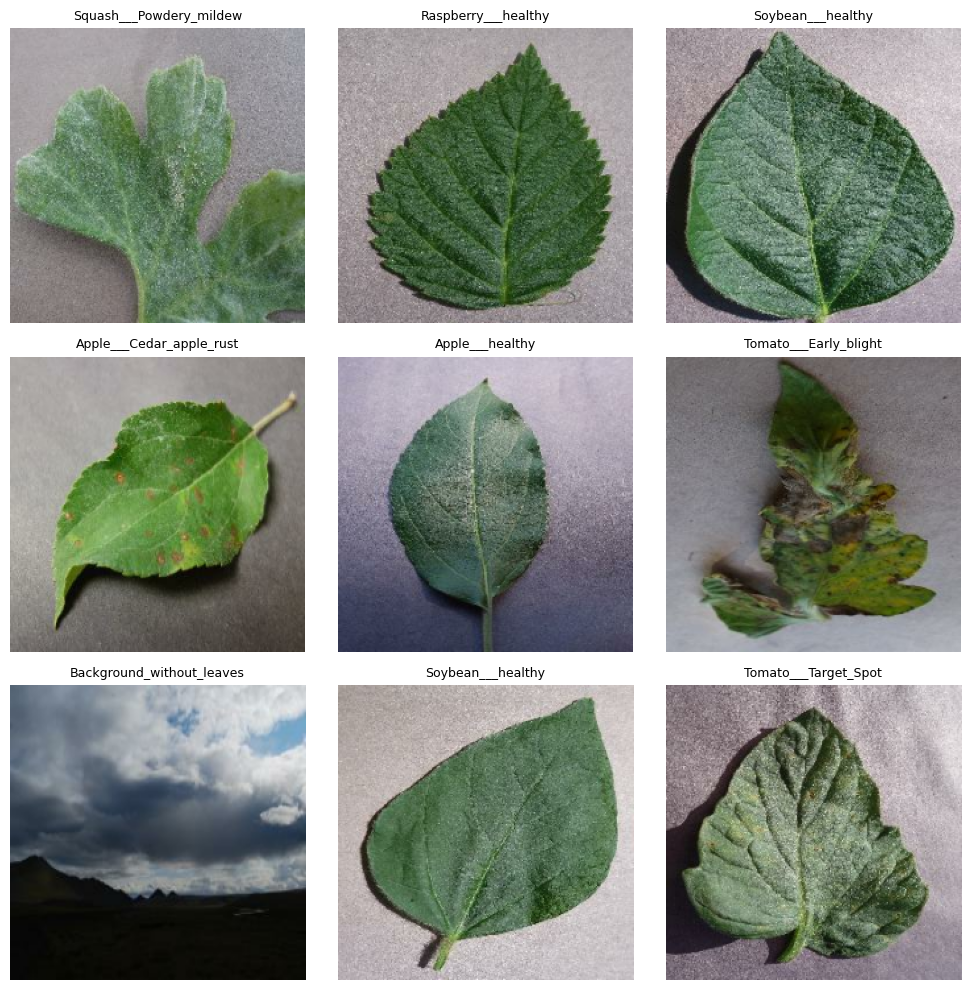

================================================== Train Test and Validation Data Creation ==================================================
Total Classes: 39
Train samples: 49188
Val samples: 6149
Test samples: 6149
================================================== Preprocessing , Train Test and validation Pipeline ==================================================
Total Time Taken : 0.0830200990041097 Minutes
Data pipeline optimization complete!


In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import keras_tuner as kt
import random
import json

tf.keras.utils.set_random_seed(42)

start_time=time.time()

print(f'{50*'='} Dataset Folder Validation {50*'='}')
base_dir = '/kaggle/working/dataset'
inner_folder = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f)) and f != '.virtual_documents'][0]
data_dir = os.path.join(base_dir, inner_folder)

if  os.path.exists(data_dir):
    folders=[f for f in os.listdir(data_dir)]
    print(f'path exists! Found {len(folders)} class subfolders')
    print("Sample folder names:")
    for f in folders:
        print(f"  - {f}")
else:
    print(f"Error: Path '{data_dir}' does not exist. Please check the spelling.")

print(f'{50*'='} importing Dataset {50*'='}')

full_ds=tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels='inferred',
    label_mode='int',
    batch_size=None,
    image_size=(224,224),
    shuffle=True,
    seed=42
)
class_names = full_ds.class_names
num_classes = len(class_names)
print("\n--- Dataset Info ---")
print(f"Total Images: {len(full_ds)}")
print(f"Total Classes: {num_classes}")


print(f'{50*'='} random dataset  validation {50*'='}')

plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(full_ds.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(class_names[label.numpy()], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


print(f'{50*'='} Train Test and Validation Data Creation {50*'='}')

file_paths=[]
labels=[]
class_names=sorted(os.listdir(data_dir))
class_to_index={name:i for i,name in enumerate(class_names)}

for class_name in class_names:
    class_dir=os.path.join(data_dir,class_name)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            file_paths.append(os.path.join(class_dir,img_name))
            labels.append(class_to_index[class_name])

combined = list(zip(file_paths, labels))
random.seed(42)
random.shuffle(combined)
file_paths,labels=zip(*combined)

total_size = len(file_paths)
train_end = int(0.8 * total_size)
val_end = int(0.9 * total_size)
train_paths, train_labels = file_paths[:train_end], labels[:train_end]
val_paths, val_labels = file_paths[train_end:val_end], labels[train_end:val_end]
test_paths, test_labels = file_paths[val_end:], labels[val_end:]
num_classes = len(class_names)
print(f"Total Classes: {num_classes}")
print(f"Train samples: {len(train_paths)}")
print(f"Val samples: {len(val_paths)}")
print(f"Test samples: {len(test_paths)}")


print(f'{50*'='} Preprocessing , Train Test and validation Pipeline {50*'='}')

def load_and_preprocess(path,label):
    img=tf.io.read_file(path)
    img=tf.image.decode_image(img,channels=3,expand_animations=False)
    img=tf.image.resize(img,(224,224))
    img=tf.cast(img,tf.float32)/255.0
    img.set_shape((224,224,3))
    return img,label

ds_train=tf.data.Dataset.from_tensor_slices((list(train_paths),list(train_labels)))
ds_val=tf.data.Dataset.from_tensor_slices((list(val_paths),list(val_labels)))
ds_test=tf.data.Dataset.from_tensor_slices((list(test_paths),list(test_labels)))


batch_size=32
autotune=tf.data.AUTOTUNE

train_pipeline=ds_train.map(load_and_preprocess,num_parallel_calls=autotune)
train_pipeline=train_pipeline.shuffle(buffer_size=1000)
train_pipeline=train_pipeline.batch(batch_size)
train_pipeline=train_pipeline.prefetch(buffer_size=autotune)

val_pipeline=ds_val.map(load_and_preprocess,num_parallel_calls=autotune)
val_pipeline=val_pipeline.batch(batch_size)
val_pipeline=val_pipeline.prefetch(buffer_size=autotune)


test_pipeline=ds_test.map(load_and_preprocess,num_parallel_calls=autotune)
test_pipeline=test_pipeline.batch(batch_size)
test_pipeline=test_pipeline.prefetch(buffer_size=autotune)

end_time=time.time()
print(f'Total Time Taken : {(end_time-start_time)/60} Minutes')

print("Data pipeline optimization complete!")

### Designing Yolo v8 Blocks and Transformer Encoder

In [7]:
#### =============================================CBS Block=================================================
class Cbs_Block(tf.keras.layers.Layer):
    def __init__(self,filters,kernel_size,strides=1,padding='same',**kwargs):

        super().__init__(**kwargs)
        self.conv=tf.keras.layers.Conv2D(filters,kernel_size,strides=strides,padding=padding,use_bias=False)
        self.bn=tf.keras.layers.BatchNormalization()
        self.act=tf.keras.layers.Activation('silu')

    def call(self,x,training=False):
        return self.act(self.bn(self.conv(x),training=training))


####===============================================C2f Block================================================
class C2f_Block(tf.keras.layers.Layer):
    def __init__(self,filters,num_bottleneck=1,shortcut=True,**kwargs):

        super().__init__(**kwargs)
        self.filter_branch=filters//2
        self.c2f_cbs_top=Cbs_Block(filters=2*self.filter_branch,kernel_size=1)
        self.c2f_cbs_bottom=Cbs_Block(filters=filters,kernel_size=1)
        self.bottlenecks=[BottleNeck(self.filter_branch,shortcut=True) for _ in range(num_bottleneck)]

    def call(self,x,training=False):
        split_candidate=self.c2f_cbs_top(x,training=training)
        y=list(tf.split(split_candidate,num_or_size_splits=2,axis=-1))

        for m in self.bottlenecks:
            y.append(m(y[-1],training=training))

        merged=tf.keras.layers.Concatenate(axis=-1)(y)

        return self.c2f_cbs_bottom(merged,training=training)

####============================================Bottleneck Inside C2f Block=====================================

class BottleNeck(tf.keras.layers.Layer):
    def __init__(self,filters,shortcut=True,**kwargs):
        super().__init__(**kwargs)
        self.cbs1=Cbs_Block(filters,kernel_size=3)
        self.cbs2=Cbs_Block(filters,kernel_size=3)
        self.shortcut=shortcut

    def call(self,x,training=False):
        out=self.cbs2(self.cbs1(x,training=training),training=training)
        return x+out if self.shortcut else out
    

####=============================================SPPF layer=======================================================
    
class Sppf_Block(tf.keras.layers.Layer):
    def __init__(self,filters,pool_size=5,**kwargs):
        super().__init__(**kwargs)
        self.filter_branch=filters//2
        self.sppf_cbs_top=Cbs_Block(self.filter_branch,1)
        self.sppf_cbs_bottom=Cbs_Block(filters,1)
        self.pool=tf.keras.layers.MaxPooling2D(pool_size=pool_size,strides=1,padding='same')


    def call(self,x,training=False):
        x_sppf_cbs_top=self.sppf_cbs_top(x,training=training)
        y1=self.pool(x_sppf_cbs_top)
        y2=self.pool(y1)
        y3=self.pool(y2)

        merged=tf.keras.layers.Concatenate(axis=-1)([x_sppf_cbs_top,y1,y2,y3])

        return self.sppf_cbs_bottom(merged,training=training)

### ============================================Positional Enbedding ============================================== 

class Static_Positional_Embedding(tf.keras.layers.Layer):
    def __init__(self,seq_len,d_model,**kwargs):
        super().__init__(**kwargs)
        self.seq_len=seq_len
        self.d_model=d_model


        sentence_positional_vector_list=[]

        for word_position in range(self.seq_len):

            word_position_vector=[]
            for i in range(int((self.d_model/2))):
                y_sin=np.sin(word_position/10000**((2*i)/self.d_model))
                y_cos=np.cos(word_position/10000**((2*i)/self.d_model))
                word_position_vector.append(y_sin)
                word_position_vector.append(y_cos)

            sentence_positional_vector_list.append(word_position_vector)

        encoding_matrix= np.array(sentence_positional_vector_list)
        self.positional_encoding=tf.constant(encoding_matrix,dtype=tf.float32)[None,...]

    def call(self,x):
        return x+self.positional_encoding
    
####=============================================Transformer Encoder============================================================

class Transformer_Encoder(tf.keras.layers.Layer):

    def __init__(self,num_heads,d_model,ff_dim,dropout=0.1,kernel_regularizer=None,**kwargs):
        super().__init__(**kwargs)

        self.mha=tf.keras.layers.MultiHeadAttention(num_heads=num_heads,key_dim=d_model,value_dim=d_model)
        self.ffn=tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim,activation='relu',kernel_regularizer=kernel_regularizer),
            tf.keras.layers.Dense(d_model,kernel_regularizer=kernel_regularizer)
        ])
        self.layernorm_mha=tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm_ffn=tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout_mha=tf.keras.layers.Dropout(dropout)
        self.dropout_ffn=tf.keras.layers.Dropout(dropout)


    def call(self,x,training=False):
        #Multi-Head Attention and residual connection
        attn_output=self.mha(x,x,x,training=training)
        attn_output=self.dropout_mha(attn_output,training=training)
        out1=self.layernorm_mha(x+attn_output)

        #Feed Forward network and residual connection
        ffn_output=self.ffn(out1,training=training)
        ffn_output=self.dropout_ffn(ffn_output,training=training)
        return self.layernorm_ffn(out1+ffn_output)



### Building Yolov8 Model with Transformers encoders as classification head

In [9]:
class Build_HyperCNNmodel(kt.HyperModel):

    def __init__(self,num_classes,model_save_path,img_size=224,**kwargs):
        super().__init__(**kwargs)
        self.num_classes=num_classes
        self.img_size=img_size
        self.model_save_path=model_save_path

    def build(self,hp):
        inputs=tf.keras.layers.Input(shape=(self.img_size,self.img_size,3))

    ## Yolo v8
        ## Data Augmentation
        x=tf.keras.layers.RandomFlip('horizontal_and_vertical')(inputs)
        x=tf.keras.layers.RandomRotation(0.2)(x)
        x=tf.keras.layers.RandomContrast(0.15)(x)
        x=tf.keras.layers.RandomZoom(0.1)(x)


        ### CSPDarknet
        #stem 112x112
        #0
        x=Cbs_Block(filters=8,kernel_size=3,strides=2)(x)
        
        ## stage1:56x56
        #1
        x=Cbs_Block(filters=16,kernel_size=3,strides=2)(x)
        #2
        x=C2f_Block(filters=16,num_bottleneck=1)(x)
        
        #stage2:28x28
        #3 
        x=Cbs_Block(filters=32,kernel_size=3,strides=2)(x)
        #4
        p3=C2f_Block(filters=32,num_bottleneck=2)(x)
        
        #stage3:14x14
        #5 
        x=Cbs_Block(filters=64,kernel_size=3,strides=2)(p3)
        #6
        p4=C2f_Block(filters=64,num_bottleneck=2)(x)

        #stage4:7x7
        #7
        x=Cbs_Block(filters=128,kernel_size=3,strides=2)(p4)
        #8
        x=C2f_Block(filters=128,num_bottleneck=1)(x)
        #9
        p5=Sppf_Block(filters=128)(x)



        # Neck(FPN+PAnet)

        #FPN Top-Down Path
        # Upsampling p3 to match p4 and then to p5 to match p5 to perform concatenation after each upsampling
        #p5-to-p4 (14x14)
        #10 
        p5_up_p4=tf.keras.layers.UpSampling2D(size=(2,2),interpolation='nearest')(p5)
        #11
        p4_merge=tf.keras.layers.Concatenate(axis=-1)([p5_up_p4,p4])
        #12
        p4_fused=C2f_Block(filters=64,num_bottleneck=3,shortcut=False)(p4_merge)

        #p4-to-p3 (28x28)
        #13
        p4_up_p3=tf.keras.layers.UpSampling2D(size=(2,2),interpolation='nearest')(p4_fused)
        #14
        p3_merge=tf.keras.layers.Concatenate(axis=-1)([p4_up_p3,p3])
        #15
        p3_fused_ph_1=C2f_Block(filters=32,num_bottleneck=3,shortcut=False)(p3_merge)

        ##PANet Bottom-Up Pathway
        ##Downsampling match p3 to p4 and p4 to p5
        #p3-to-p4 (14x14)
        #16
        p3_down_p4=Cbs_Block(filters=32,kernel_size=3,strides=2)(p3_fused_ph_1)
        #17
        p4_merge2=tf.keras.layers.Concatenate(axis=-1)([p3_down_p4,p4_fused])
        #18
        p4_fused_ph_2=C2f_Block(filters=64,num_bottleneck=3,shortcut=False)(p4_merge2)

        #p4-to-p5(7x7)
        #19
        p4_down_p5=Cbs_Block(filters=64,kernel_size=3,strides=2)(p4_fused_ph_2)
        #20
        p5_merge2=tf.keras.layers.Concatenate(axis=-1)([p4_down_p5,p5])
        #21
        p5_fused_ph_3=C2f_Block(filters=128,num_bottleneck=3,shortcut=False)(p5_merge2)


        ### Multi-Scale Classification Head & Transformers

        g3=tf.keras.layers.GlobalAveragePooling2D()(p3_fused_ph_1)
        g4=tf.keras.layers.GlobalAveragePooling2D()(p4_fused_ph_2)

        flattened_x=tf.keras.layers.Reshape((49,128))(p5_fused_ph_3)
        transformer_input_x=Static_Positional_Embedding(seq_len=49,d_model=128)(flattened_x)

        #==================
        reg_type=hp.Choice('reg_type',['l1','l2','l1_l2','None'])
        if reg_type=='l1':
            reg=tf.keras.regularizers.L1(
                l1=hp.Float('l1',min_value=1e-6,max_value=1e-3,sampling='log')
            )
        elif reg_type=='l2':
            reg=tf.keras.regularizers.L2(
                l2=hp.Float('l2',min_value=1e-6,max_value=1e-3,sampling='log')
            )
        elif reg_type=='l1_l2':
            reg=tf.keras.regularizers.L1L2(
                l1=hp.Float('l1',min_value=1e-6,max_value=1e-3,sampling='log'),
                l2=hp.Float('l2',min_value=1e-6,max_value=1e-3,sampling='log')
            )
        else:
            reg=None
        #===============================

        transformer_output=Transformer_Encoder(num_heads=4,d_model=128,ff_dim=512,dropout=0.1,kernel_regularizer=reg)(transformer_input_x)

        g5=tf.keras.layers.GlobalAveragePooling1D()(transformer_output)
        merged_features=tf.keras.layers.Concatenate(axis=-1)([g3,g4,g5])

        x_head=tf.keras.layers.Dropout(0.3)(merged_features)
        outputs=tf.keras.layers.Dense(self.num_classes,activation='softmax',kernel_regularizer=reg)(x_head)

        model=tf.keras.Model(inputs=inputs,outputs=outputs,name='yolov8_transformer_classifier')

        learning_rate=hp.Float(name='lr',min_value=1e-4,max_value=1e-1,sampling='log')   
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=['accuracy']
        )

        return model
    
    def fit(self,hp,model,x,y=None,*args,**kwargs):
        
        if not os.path.exists(self.model_save_path):
            os.makedirs(self.model_save_path,exist_ok=True)

        model_checkpoint=tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(self.model_save_path,"best_hypermodel.weights.h5"),
            monitor='val_accuracy',
            verbose=1,
            save_best_only=True,
            save_weights_only=True,
            mode='max',
            save_freq='epoch'
        )

        early_stopping=tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            min_delta=0.005,
            patience=5,
            verbose=1,
            mode='max',
            restore_best_weights=True
        )

        reduce_lr=tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )

        callbacks=kwargs.pop('callbacks',[])
        callbacks.append(model_checkpoint)
        callbacks.append(early_stopping)
        callbacks.append(reduce_lr)

        return model.fit(
            x=x,
            y=None,
            epochs=hp.Int('epochs',min_value=10,max_value=30,step=5),
            callbacks=callbacks,
            verbose='auto',
            **kwargs
        )

## Searching For Best Parameters for laerning rate and regularization and epochs

In [10]:
tuner_start=time.time()
hyperCNNmodel=Build_HyperCNNmodel(num_classes=num_classes,model_save_path=r'models',img_size=224)


hp=kt.HyperParameters()
model_test=hyperCNNmodel.build(hp)
model_test.summary()


tuner_log_path=r"tuner_logs"
if not os.path.exists(tuner_log_path):
    os.makedirs(tuner_log_path,exist_ok=True)

param_tuner=kt.BayesianOptimization(
    hypermodel=hyperCNNmodel,
    objective='val_accuracy',
    max_trials=5,
    seed=42,
    executions_per_trial=1,
    overwrite=True,
    directory=tuner_log_path,
    project_name='yolv8_transformer_tuner'
)

tuner_train = train_pipeline.take(70)
tuner_val = val_pipeline.take(35)

param_tuner.search(
    x=tuner_train,
    validation_data=tuner_val
)

tuner_end=time.time()
print(f'total tuner time {(tuner_end-tuner_start)/(60*60)} Hours')

Trial 5 Complete [00h 01m 36s]
val_accuracy: 0.09375

Best val_accuracy So Far: 0.6776785850524902
Total elapsed time: 00h 14m 51s
total tuner time 0.25012708683808643 Hours


In [13]:
train_start=time.time()
best_hp=param_tuner.get_best_hyperparameters()[0]

best_model=param_tuner.hypermodel.build(best_hp)

best_hps_dict = best_hp.values
best_hps_filepath = "best_hps.json"
with open(best_hps_filepath, "w") as f:
    json.dump(best_hps_dict, f, indent=4)
print(f"💾 Best hyperparameters saved to '{best_hps_filepath}'")

final_epochs=best_hp.get('epochs')

print(f'\n Starting Final Training of the model for {final_epochs} epochs')
history=hyperCNNmodel.fit(
    hp=best_hp,
    model=best_model,
    x=train_pipeline,
    validation_data=val_pipeline,
)

train_end=time.time()
final_weights_path=r'final_plant_disease_detection_model.weights.h5'

best_hps_dict = best_hp.values
best_hps_filepath = "best_hps.json"
with open(best_hps_filepath, "w") as f:
    json.dump(best_hps_dict, f, indent=4)
print(f"💾 Best hyperparameters saved to '{best_hps_filepath}'")

best_model.save_weights(final_weights_path)
print(f'Final weights saved successfully to : {final_weights_path}')
print(f'Total Training Time : {(train_end-train_start)/(60*60)} Hours')

💾 Best hyperparameters saved to 'best_hps.json'

 Starting Final Training of the model for 30 epochs
Epoch 1/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.2612 - loss: 3.4703
Epoch 1: val_accuracy improved from None to 0.17629, saving model to models/best_hypermodel.weights.h5

Epoch 1: finished saving model to models/best_hypermodel.weights.h5
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 197s 105ms/step - accuracy: 0.3828 - loss: 2.6574 - val_accuracy: 0.1763 - val_loss: 8.9845 - learning_rate: 0.0861
Epoch 2/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5518 - loss: 1.9278
Epoch 2: val_accuracy improved from 0.17629 to 0.25289, saving model to models/best_hypermodel.weights.h5

Epoch 2: finished saving model to models/best_hypermodel.weights.h5
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 159s 103ms/step - accuracy: 0.5870 - loss: 1.7846 - val_accuracy: 0.2529 - val_loss: 6.4626 - learning_rate: 0.0861
Epoch 3/30
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6424 - l

In [14]:
import json
import base64
from IPython.display import HTML

# 1. Extract the metrics dictionary from the history variable
history_dict = history.history

# 2. Convert it to a formatted JSON string
json_str = json.dumps(history_dict, indent=4)

# 3. Save it as a physical file on Kaggle disk
with open("training_history.json", "w") as f:
    f.write(json_str)
print("✓ Saved to disk as 'training_history.json'")

# 4. Generate a direct browser download link
b64 = base64.b64encode(json_str.encode()).decode()
href = f'<a href="data:file/json;base64,{b64}" download="training_history.json" style="color: #10B981; font-weight: bold; font-size: 16px;">👉 Click here to download training_history.json</a>'

HTML(href)

✓ Saved to disk as 'training_history.json'
